  OPTIMISATION RESULT
  Optimal velocity  : 140.18  m/s
  Optimal altitude  : 7979.6  m
  Min fuel flow rate: 93.0658  g/s
  Air density at h  : 0.5262  kg/m³
  C_L at optimum    : 0.6325
  C_D at optimum    : 0.0400
  L/D at optimum    : 15.81

Contour plot saved →  fuel_flow_contour.png


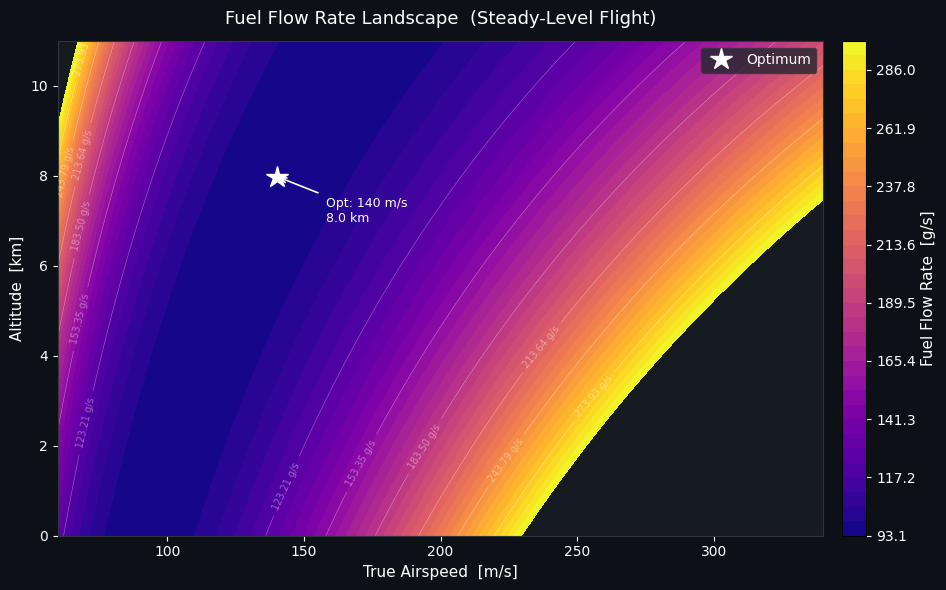

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os
# 1.AIRCRAFT & ENGINE PARAMETERS
g    = 9.81 #gravitational acceleration  [m/s²]
m    = 10_000 #aircraft mass               [kg]
W    = m * g #weight                      [N]
S    = 30.0 #wing reference area          [m²]
CD0  = 0.02 #zero-lift drag coefficient  [-]
K    = 0.05 #induced-drag factor          [-]
TSFC = 1.5e-5 #thrust-specific fuel consumption [kg/(N·s)]
#TSFC links thrust to fuel burn: m_dot_fuel = TSFC * T
#2. INTERNATIONAL STANDARD ATMOSPHERE (ISA) – TROPOSPHERE ONLY
#Valid from sea level to 11 000 m (the tropopause).
def isa_density(h):
    """
    Returns air density rho [kg/m³] at altitude h [m] using the ISA model.

    The temperature lapse rate in the troposphere is -6.5 K/km, giving:
        T(h) = T0 * (1 - L*h/T0)    where L = 0.0065 K/m
    Density then follows from the hydrostatic equation:
        rho(h) = rho0 * (T(h)/T0)^(g/(L*R) - 1)
    which simplifies to the standard ISA density formula below.
    """
    T0   = 288.15   #sea-level temperature[K]
    rho0 = 1.225    #sea-level density[kg/m³]
    L    = 0.0065   #lapse rate[K/m]
    R    = 287.05   #specific gas constant[J/(kg·K)]
    #Clamp altitude to the troposphere for this model
    h = np.clip(h, 0, 11_000)
    #Temperature ratio
    T_ratio = 1 - (L * h) / T0
    #Density via barometric formula
    exponent = g / (L * R) - 1          # ≈ 4.256
    return rho0 * T_ratio ** exponent
# 3.FUEL FLOW RATE FUNCTION  (the objective we are minimising)
def fuel_flow(v, h):
    """
    Computes fuel mass flow rate [kg/s] for a given speed v [m/s]
    and altitude h [m], assuming steady-level flight.

    Steps:
      1. Get air density at altitude h.
      2. Compute dynamic pressure  q = 0.5 * rho * v²
      3. From L=W, derive C_L = W / (q * S)
      4. Compute C_D via parabolic polar
      5. Compute Drag D = q * S * C_D
      6. Since T = D:  m_dot = TSFC * D
    """
    rho  = isa_density(h)
    q    = 0.5 * rho * v**2             # dynamic pressure [Pa]
    CL   = W / (q * S)                  # lift coefficient
    CD   = CD0 + K * CL**2              # total drag coefficient
    D    = q * S * CD                   # drag = thrust [N]
    return TSFC * D                     # fuel flow [kg/s]
# 4.SCIPY OPTIMISATION
#We minimise fuel_flow(v, h) over the continuous variables (v, h).
#The objective is wrapped to accept a single vector x = [v, h].
def objective(x):
    v, h = x
    return fuel_flow(v, h)

#Initial guess: typical cruise speed and altitude
x0 = [200.0, 8_000.0]      #[m/s], [m]

#Bounds: physically sensible flight envelope
bounds = [
    (50,  350),             #velocity:  50–350 m/s
    (0,  11_000),           #altitude:  sea level to tropopause
]

result = minimize(
    objective,
    x0,
    method='L-BFGS-B',     #gradient-based, supports bounds
    bounds=bounds,
    options={'ftol': 1e-12, 'gtol': 1e-10}
)

v_opt = result.x[0]
h_opt = result.x[1]
mdot_opt = result.fun

print("=" * 55)
print("  OPTIMISATION RESULT")
print("=" * 55)
print(f"  Optimal velocity  : {v_opt:.2f}  m/s")
print(f"  Optimal altitude  : {h_opt:.1f}  m")
print(f"  Min fuel flow rate: {mdot_opt*1000:.4f}  g/s")
print(f"  Air density at h  : {isa_density(h_opt):.4f}  kg/m³")
rho_opt = isa_density(h_opt)
CL_opt  = W / (0.5 * rho_opt * v_opt**2 * S)
CD_opt  = CD0 + K * CL_opt**2
print(f"  C_L at optimum    : {CL_opt:.4f}")
print(f"  C_D at optimum    : {CD_opt:.4f}")
print(f"  L/D at optimum    : {CL_opt/CD_opt:.2f}")
print("=" * 55)
# 5.CONTOUR PLOT–fuel flow landscape across (v, h)
v_range = np.linspace(60, 340, 300)
h_range = np.linspace(0, 11_000, 300)
V, H    = np.meshgrid(v_range, h_range)
#Vectorised calculation of fuel flow over the entire grid
MDOT = fuel_flow(V, H)   # numpy broadcasting handles arrays
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
#Filled contours (log scale to reveal the valley structure clearly)
levels = np.linspace(MDOT.min(), np.percentile(MDOT, 85), 35)
cf = ax.contourf(V, H / 1000, MDOT * 1000,   # convert h → km, mdot → g/s
                  levels=levels * 1000,
                  cmap='plasma')
#Contour lines for readability
cs = ax.contour(V, H / 1000, MDOT * 1000,
                levels=levels[::5] * 1000,
                colors='white', linewidths=0.4, alpha=0.4)
ax.clabel(cs, fmt='%.2f g/s', fontsize=7, colors='white')
#Colour bar
cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('Fuel Flow Rate  [g/s]', color='white', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
#Mark the optimum
ax.plot(v_opt, h_opt / 1000, 'w*', markersize=16, label='Optimum', zorder=5)
ax.annotate(
    f'  Opt: {v_opt:.0f} m/s\n  {h_opt/1000:.1f} km',
    xy=(v_opt, h_opt / 1000),
    color='white', fontsize=9,
    xytext=(v_opt + 15, h_opt / 1000 - 1.0),
    arrowprops=dict(arrowstyle='->', color='white', lw=1.2)
)

ax.set_xlabel('True Airspeed  [m/s]', color='white', fontsize=11)
ax.set_ylabel('Altitude  [km]', color='white', fontsize=11)
ax.set_title('Fuel Flow Rate Landscape  (Steady-Level Flight)',
             color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')
ax.legend(facecolor='#21262d', edgecolor='#30363d',
          labelcolor='white', fontsize=10)

plt.tight_layout()
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/fuel_flow_contour.png',
            dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
print("\nContour plot saved →  fuel_flow_contour.png")
plt.show()